# 04 — Physics Features and Rules

**Goal:** test the three hypotheses from M3 and answer the central question of this project:

> Does a black-box model beat a few lines of physics, and what is the best achievable
> performance on this data?

| # | Failure mode | Hypothesis from M3 |
|---|---|---|
| H1 | Power failure | fails if power < ~3.5 kW or > ~9 kW |
| H2 | Overstrain failure | fails if tool wear × torque > ~11k min·Nm (maybe type-dependent) |
| H3 | Heat dissipation failure | fails if temp difference < ~8.5 K **and** rpm < ~1,400 |

Plan:
1. compute the physics features
2. find the exact thresholds in the data
3. check the rules against the failure-mode labels
4. compare four approaches with the same cross-validation as M2
5. quantify the performance ceiling

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from pdm.config import FIGURES_DIR, PROJECT_ROOT
from pdm.data import FAILURE_MODES, FEATURES, MACHINE_TYPES, TARGET, load_data
from pdm.evaluate import classification_metrics, compare_models, make_cv
from pdm.features import PHYSICS_FEATURES, add_physics_features
from pdm.models import baseline_models
from pdm.rules import (
    HEAT_RPM_MAX,
    HEAT_TEMP_DIFF_MAX_K,
    POWER_MAX_W,
    POWER_MIN_W,
    RULE_MODES,
    STRAIN_LIMIT_MIN_NM,
    PhysicsRuleClassifier,
    RulesThenModel,
    rule_flags,
)

sns.set_theme(style="whitegrid", context="notebook")
REPORTS_DIR = PROJECT_ROOT / "reports"
GREY, RED = "#8d99ae", "#d1495b"


def save(fig, name):
    fig.savefig(FIGURES_DIR / f"04_{name}.png", dpi=150, bbox_inches="tight")

In [2]:
df = load_data()
X, y = df[FEATURES], df[TARGET]
f = add_physics_features(df)
f[["type", *FEATURES[1:], *PHYSICS_FEATURES]].head()

,type,air_temp_k,process_temp_k,rpm,torque_nm,tool_wear_min,temp_diff_k,power_w,strain_min_nm
0,M,298.1,308.6,1551,42.8,0,10.5,6951.590560,0.0
1,L,298.2,308.7,1408,46.3,3,10.5,6826.722724,138.9
2,L,298.1,308.5,1498,49.4,5,10.4,7749.387543,247.0
3,L,298.2,308.6,1433,39.5,7,10.4,5927.504659,276.5
4,L,298.2,308.7,1408,40.0,9,10.5,5897.816608,360.0


## 1. Physics features

All three features are computed in `src/pdm/features.py`. With `physics=True`, the model pipelines
derive them automatically from the raw inputs.

| Feature | Formula | Unit | Physical meaning |
|---|---|---|---|
| `temp_diff_k` | process temp − air temp | K | Driving force for heat flow out of the process |
| `power_w` | torque · rpm · 2π / 60 | W | Mechanical power at the spindle |
| `strain_min_nm` | tool wear · torque | min·Nm | Load on an already worn tool |

## 2. Finding the thresholds in the data

For each rule we look for the **gap** between failing and non-failing rows. For example, for the
lower power limit: what is the highest power of a power-failure row, and the lowest power of any
other row? If the classes are cleanly separated, any threshold inside the gap classifies every row
correctly.

We use the failure-mode labels here, not the target. Then we compare the gaps with the limits given
in the dataset documentation (Matzka, 2020). In a real plant, these limits would come from machine
specifications.

In [3]:
pwf, no_pwf = f[f["pwf"] == 1], f[f["pwf"] == 0]
hdf, no_hdf = f[f["hdf"] == 1], f[f["hdf"] == 0]

rows = [
    (
        "Power",
        "power_w below",
        pwf.loc[pwf["power_w"] < 6000, "power_w"].max(),
        no_pwf["power_w"].min(),
        POWER_MIN_W,
    ),
    (
        "Power",
        "power_w above",
        no_pwf["power_w"].max(),
        pwf.loc[pwf["power_w"] > 6000, "power_w"].min(),
        POWER_MAX_W,
    ),
]
for t in MACHINE_TYPES:
    d = f[f["type"] == t]
    rows.append(
        (
            f"Overstrain, type {t}",
            "strain_min_nm above",
            d.loc[d["osf"] == 0, "strain_min_nm"].max(),
            d.loc[d["osf"] == 1, "strain_min_nm"].min(),
            STRAIN_LIMIT_MIN_NM[t],
        )
    )
rows += [
    (
        "Heat dissipation",
        "rpm below",
        hdf["rpm"].max(),
        no_hdf.loc[no_hdf["temp_diff_k"] < HEAT_TEMP_DIFF_MAX_K, "rpm"].min(),
        HEAT_RPM_MAX,
    ),
    (
        "Heat dissipation",
        "temp_diff_k below",
        hdf["temp_diff_k"].max(),
        no_hdf.loc[no_hdf["rpm"] < HEAT_RPM_MAX, "temp_diff_k"].min(),
        HEAT_TEMP_DIFF_MAX_K,
    ),
]
gaps = pd.DataFrame(
    rows, columns=["failure mode", "condition", "gap from", "gap to", "documented limit"]
)
gaps["limit inside gap"] = (gaps["gap from"] <= gaps["documented limit"]) & (
    gaps["documented limit"] <= gaps["gap to"]
)
gaps.style.format({"gap from": "{:,.1f}", "gap to": "{:,.1f}", "documented limit": "{:,.1f}"})

,failure mode,condition,gap from,gap to,documented limit,limit inside gap
0,Power,power_w below,"3,477.2","3,515.0","3,500.0",True
1,Power,power_w above,"8,998.0","9,004.4","9,000.0",True
2,"Overstrain, type L",strain_min_nm above,"10,993.8","11,003.2","11,000.0",True
3,"Overstrain, type M",strain_min_nm above,"11,919.8","12,337.2","12,000.0",True
4,"Overstrain, type H",strain_min_nm above,"11,872.8","13,234.8","13,000.0",True
5,Heat dissipation,rpm below,"1,379.0","1,381.0","1,380.0",True
6,Heat dissipation,temp_diff_k below,8.6,8.6,8.6,True


Every documented limit lies inside the gap found in the data, so the M3 hypotheses were right.
The SHAP-based estimates were also close: about 3.5 and 9 kW for power, about 11k min·Nm for overstrain,
and about 8.5 K and 1,400 rpm for heat dissipation.

- **Power:** the gaps are narrow (3,477–3,515 W and 8,998–9,004 W), so the data pins the limits
  down precisely.
- **Overstrain:** the limit **depends on machine type**. The gap for type L is 10,994–11,003, which
  rules out a shared limit for all types. For M and H there are fewer overstrain cases, so the gaps
  are wider, but the documented limits of 12k and 13k fit. Higher quality machines tolerate more load.
- **Heat dissipation:** the gap for the temperature difference has zero width, which needs a closer look.

## 3. A labelling detail: floating-point rounding decides 27 rows

In [4]:
boundary = f[(f["temp_diff_k"].round(1) == 8.6) & (f["rpm"] < HEAT_RPM_MAX)].copy()
boundary["temp_diff (exact float)"] = boundary["temp_diff_k"].map(repr)
print(f"Rows with temp difference of exactly 8.6 K and rpm < {HEAT_RPM_MAX}: {len(boundary)}")
print(f"  labelled as heat dissipation failure: {boundary['hdf'].sum()}")
boundary[["air_temp_k", "process_temp_k", "temp_diff (exact float)", "rpm", "hdf"]].head(8)

Rows with temp difference of exactly 8.6 K and rpm < 1380: 27
  labelled as heat dissipation failure: 12


,air_temp_k,process_temp_k,temp_diff (exact float),rpm,hdf
3236,300.8,309.4,8.599999999999966,1342,1
3760,302.3,310.9,8.599999999999966,1377,1
3764,302.4,311.0,8.600000000000023,1329,0
3793,302.3,310.9,8.599999999999966,1379,1
3794,302.2,310.8,8.600000000000023,1356,0
3806,302.3,310.9,8.599999999999966,1360,1
3809,302.2,310.8,8.600000000000023,1350,0
3829,302.3,310.9,8.599999999999966,1366,1


Temperatures are stored with one decimal, so 27 slow-spindle rows have a temperature difference of
exactly 8.6 K. The labels still split 12 to 15. Whether a row counts as a failure depends on how the
subtraction rounds in binary floating point: `310.9 − 302.3 = 8.5999…` is a failure, while
`311.0 − 302.4 = 8.6000…` is not.

So the dataset generator applied `temp_diff < 8.6` to floating-point results, and these 27 labels are
an artefact of that. Our rule reproduces them only because it performs the same subtraction.
A physically "clean" rule on the rounded values would get 12 or 15 of these rows wrong.

**Lesson:** a model or rule that reaches 100% agreement is not necessarily learning physics. It can
also be reproducing an artefact of how the labels were generated. With real sensor data, rows this
close to a boundary would simply be noisy.

## 4. The three rules against their labels

In [5]:
flags = rule_flags(X)
labels = df[list(RULE_MODES)]
pd.DataFrame(
    {
        "rule fires": flags.sum(),
        "label = 1": labels.sum(),
        "mismatches": (flags.astype(int) != labels).sum(),
        "agreement": (flags.astype(int) == labels).mean(),
    }
).rename(index=RULE_MODES).style.format({"agreement": "{:.2%}"})

,rule fires,label = 1,mismatches,agreement
Power failure,95,95,0,100.00%
Overstrain failure,98,98,0,100.00%
Heat dissipation failure,115,115,0,100.00%


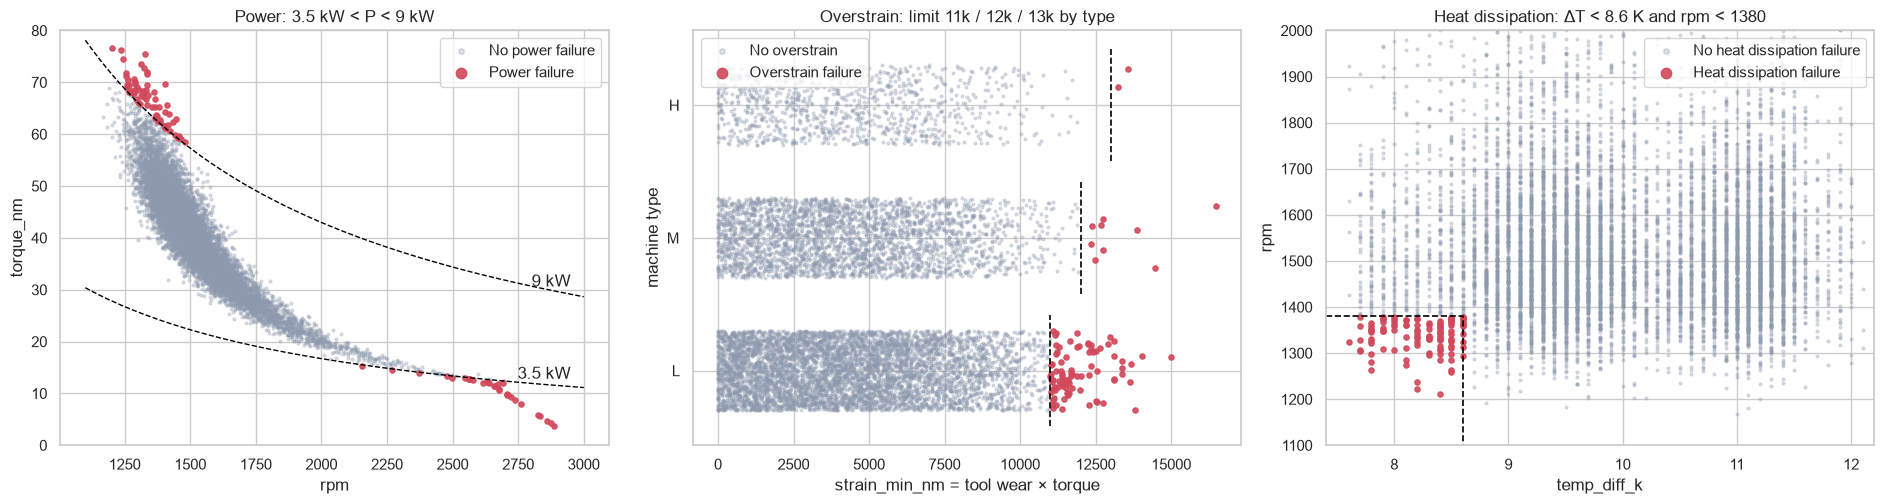

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(19, 5.2))

# Power: speed vs torque with the two iso-power limits
ax = axes[0]
for label, color, mask in [
    ("No power failure", GREY, f["pwf"] == 0),
    ("Power failure", RED, f["pwf"] == 1),
]:
    ax.scatter(
        f.loc[mask, "rpm"],
        f.loc[mask, "torque_nm"],
        s=4 if color == GREY else 14,
        alpha=0.3 if color == GREY else 0.9,
        color=color,
        label=label,
    )
rpm_grid = np.linspace(1100, 3000, 300)
for p in (POWER_MIN_W, POWER_MAX_W):
    ax.plot(rpm_grid, p / (rpm_grid * 2 * np.pi / 60), color="black", ls="--", lw=1)
    ax.text(2950, p / (2950 * 2 * np.pi / 60) + 1.5, f"{p / 1000:g} kW", ha="right")
ax.set(xlabel="rpm", ylabel="torque_nm", ylim=(0, 80), title="Power: 3.5 kW < P < 9 kW")
ax.legend(loc="upper right", markerscale=2)

# Overstrain: strain by machine type with type-specific limits
ax = axes[1]
rng = np.random.default_rng(0)
ypos = f["type"].cat.codes + rng.uniform(-0.3, 0.3, len(f))
for label, color, mask in [
    ("No overstrain", GREY, f["osf"] == 0),
    ("Overstrain failure", RED, f["osf"] == 1),
]:
    ax.scatter(
        f.loc[mask, "strain_min_nm"],
        ypos[mask],
        s=4 if color == GREY else 14,
        alpha=0.3 if color == GREY else 0.9,
        color=color,
        label=label,
    )
for i, t in enumerate(MACHINE_TYPES):
    ax.plot([STRAIN_LIMIT_MIN_NM[t]] * 2, [i - 0.42, i + 0.42], color="black", ls="--", lw=1.2)
ax.set_yticks(range(len(MACHINE_TYPES)), MACHINE_TYPES)
ax.set(
    xlabel="strain_min_nm = tool wear × torque",
    ylabel="machine type",
    title="Overstrain: limit 11k / 12k / 13k by type",
)
ax.legend(loc="upper left", markerscale=2)

# Heat dissipation: temp difference vs speed with the AND region
ax = axes[2]
for label, color, mask in [
    ("No heat dissipation failure", GREY, f["hdf"] == 0),
    ("Heat dissipation failure", RED, f["hdf"] == 1),
]:
    ax.scatter(
        f.loc[mask, "temp_diff_k"],
        f.loc[mask, "rpm"],
        s=4 if color == GREY else 14,
        alpha=0.3 if color == GREY else 0.9,
        color=color,
        label=label,
    )
ax.plot(
    [7.4, HEAT_TEMP_DIFF_MAX_K, HEAT_TEMP_DIFF_MAX_K],
    [HEAT_RPM_MAX, HEAT_RPM_MAX, 1100],
    color="black",
    ls="--",
    lw=1.2,
)
ax.set(
    xlabel="temp_diff_k",
    ylabel="rpm",
    xlim=(7.4, 12.2),
    ylim=(1100, 2000),
    title="Heat dissipation: ΔT < 8.6 K and rpm < 1380",
)
ax.legend(loc="upper right", markerscale=2)

fig.tight_layout()
save(fig, "rules")
plt.show()

All three rules reproduce their failure-mode labels on **every one of the 10,000 rows**.
These three failure modes are not probabilistic at all. They are deterministic functions of the
physics features. Unit tests in `tests/test_rules.py` lock this in.

## 5. Comparing the approaches

All approaches use the same 5-fold stratified cross-validation as M2:

| Approach | Description |
|---|---|
| ML, raw features | The M2 baseline (gradient boosting) |
| Rules only | `PhysicsRuleClassifier`: failure if any of the three rules fires. Nothing is learned. |
| ML + physics | The three M2 model types, with the physics features added |
| Hybrid | `RulesThenModel`: if a rule fires, predict failure. Otherwise use gradient boosting with physics features. |

The rules output only 0 or 1, so their PR-AUC is based on a single operating point. The hybrid adds
a proper ranking of the rows where no rule fires.

In [7]:
physics_models = baseline_models(physics=True)
approaches = {
    "ML, raw features (HGB)": baseline_models()["HistGradientBoosting"],
    "Rules only": PhysicsRuleClassifier(),
    "ML + physics (LogReg)": physics_models["LogReg (balanced)"],
    "ML + physics (RandomForest)": physics_models["RandomForest (balanced)"],
    "ML + physics (HGB)": physics_models["HistGradientBoosting"],
    "Hybrid: rules + HGB (physics)": RulesThenModel(physics_models["HistGradientBoosting"]),
}
results, probas = compare_models(approaches, X, y, cv=make_cv())
cols = ["pr_auc", "roc_auc", "precision", "recall", "f1", "tp", "fp", "fn"]
results[cols].style.format({c: "{:.3f}" for c in cols[:5]} | {c: "{:.0f}" for c in cols[5:]})

,pr_auc,roc_auc,precision,recall,f1,tp,fp,fn
model,,,,,,,,
Hybrid: rules + HGB (physics),0.906,0.980,1.000,0.847,0.917,287,0,52
ML + physics (RandomForest),0.891,0.978,0.939,0.823,0.877,279,18,60
ML + physics (HGB),0.888,0.979,0.943,0.776,0.851,263,16,76
Rules only,0.852,0.923,1.000,0.847,0.917,287,0,52
"ML, raw features (HGB)",0.835,0.978,0.801,0.758,0.779,257,64,82
ML + physics (LogReg),0.445,0.927,0.442,0.493,0.466,167,211,172


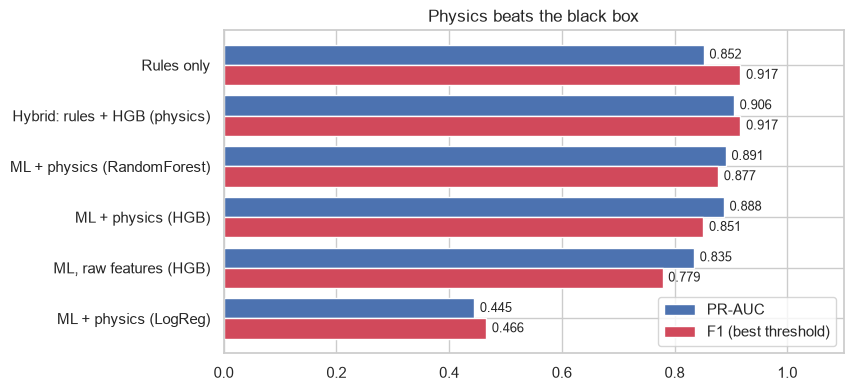

In [8]:
plot = results[["pr_auc", "f1"]].sort_values("f1")
fig, ax = plt.subplots(figsize=(8, 4.2))
ypos = np.arange(len(plot))
ax.barh(ypos + 0.2, plot["pr_auc"], height=0.4, color="#4c72b0", label="PR-AUC")
ax.barh(ypos - 0.2, plot["f1"], height=0.4, color=RED, label="F1 (best threshold)")
for i, (a, b) in enumerate(zip(plot["pr_auc"], plot["f1"], strict=True)):
    ax.text(a + 0.01, i + 0.2, f"{a:.3f}", va="center", fontsize=9)
    ax.text(b + 0.01, i - 0.2, f"{b:.3f}", va="center", fontsize=9)
ax.set_yticks(ypos, plot.index)
ax.set_xlim(0, 1.1)
ax.set_title("Physics beats the black box")
ax.legend(loc="lower right")
save(fig, "comparison")
plt.show()

- **Rules alone beat the best black box.** Three lines of physics reach F1 0.917 with **100%
  precision**: every alarm is a real failure. The raw-feature model reaches F1 0.78.
- **Physics features help every model.** Gradient boosting goes from PR-AUC 0.835 to 0.888, and the
  random forest reaches 0.891. Both still stay below the rules on F1.
- **Logistic regression stays poor** even with physics features, because each rule is an interval
  or an AND condition, which a linear model cannot represent.
- **The hybrid is best overall.** It matches the rules' F1 and adds a ranking of the remaining rows,
  which gives the highest PR-AUC (0.906). That ranking matters for choosing a threshold by cost (M5).

## 6. Why gradient boosting misses power failures, even with the power feature

Gradient boosting with `power_w` still misses some power failures, although a single split at
3,500 W and one at 9,000 W would catch them all. The reason is **histogram binning**:
`HistGradientBoostingClassifier` groups each feature into at most 255 bins at quantiles of the
training data, and can only split between bins. Power failures are rare extremes, so the tail bins
are wide:

In [9]:
power = f["power_w"]
edges = np.quantile(power, np.linspace(0, 1, 256))
for limit in (POWER_MIN_W, POWER_MAX_W):
    lo, hi = edges[edges <= limit].max(), edges[edges > limit].min()
    inside = power.between(lo, hi).sum()
    print(f"Limit {limit:>5,} W lies in the bin {lo:>6,.0f}–{hi:>6,.0f} W ({inside} rows in bin)")

Limit 3,500 W lies in the bin  1,148– 3,538 W (40 rows in bin)
Limit 9,000 W lies in the bin  8,908– 9,160 W (39 rows in bin)


Both limits fall inside a bin, so the model cannot separate the rows on either side of the limit,
no matter how many trees it uses. The edges above are approximations from quantiles of the full
dataset; the model computes its own on each training fold.

The random forest does not bin its features, which is part of why it catches more power failures.
This is a general lesson for sharp physical limits at rare extremes: a hand-written rule, or a model
without binning, is more reliable than histogram-based boosting.

## 7. Recall by failure mode

In [10]:
def recall_by_mode(name):
    caught = probas[name] >= results.loc[name, "threshold"]
    out = {}
    for mode, label in FAILURE_MODES.items():
        is_mode = (df[mode] == 1) & (y == 1)
        out[label] = f"{(caught & is_mode).sum()} / {is_mode.sum()}"
    no_mode = (y == 1) & ~df[list(FAILURE_MODES)].any(axis=1)
    out["No mode flagged"] = f"{(caught & no_mode).sum()} / {no_mode.sum()}"
    return out


pd.DataFrame({name: recall_by_mode(name) for name in results.index}).T

,Tool wear failure,Heat dissipation failure,Power failure,Overstrain failure,Random failure,No mode flagged
Hybrid: rules + HGB (physics),3 / 46,115 / 115,95 / 95,98 / 98,0 / 1,0 / 9
ML + physics (RandomForest),4 / 46,113 / 115,89 / 95,97 / 98,0 / 1,0 / 9
ML + physics (HGB),3 / 46,115 / 115,77 / 95,92 / 98,0 / 1,0 / 9
Rules only,3 / 46,115 / 115,95 / 95,98 / 98,0 / 1,0 / 9
"ML, raw features (HGB)",6 / 46,108 / 115,79 / 95,88 / 98,0 / 1,0 / 9
ML + physics (LogReg),4 / 46,53 / 115,74 / 95,57 / 98,0 / 1,0 / 9


- The rules and the hybrid catch **all** heat dissipation, power and overstrain failures.
- Every approach catches only a handful of tool wear failures, and none of the random or unexplained
  failures.

## 8. The performance ceiling

Which failures can be predicted from this data at all? Each failure is assigned to exactly one
group, in this order: a physics rule fires → tool wear failure → random failure → no mode flagged.

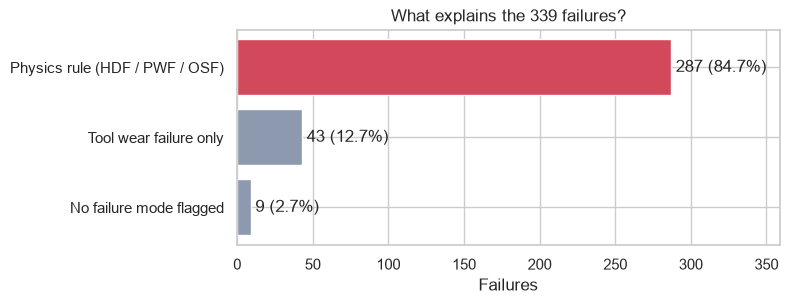

In [11]:
rule_fired = rule_flags(X).any(axis=1)
group = pd.Series(
    np.select(
        [rule_fired, df["twf"] == 1, df["rnf"] == 1],
        ["Physics rule (HDF / PWF / OSF)", "Tool wear failure only", "Random failure only"],
        "No failure mode flagged",
    ),
    index=df.index,
)
breakdown = group[y == 1].value_counts()

fig, ax = plt.subplots(figsize=(7, 2.8))
colors = [RED if g.startswith("Physics") else GREY for g in breakdown.index]
ax.barh(breakdown.index[::-1], breakdown.values[::-1], color=colors[::-1])
for i, v in enumerate(breakdown.values[::-1]):
    ax.text(v + 3, i, f"{v} ({v / y.sum():.1%})", va="center")
ax.set_xlim(0, breakdown.max() * 1.25)
ax.set_xlabel("Failures")
ax.set_title(f"What explains the {y.sum()} failures?")
save(fig, "failure_breakdown")
plt.show()

Only the failures in the first group are predictable. For tool wear failures, the dataset
documentation says the tool fails or is replaced at a random time between 200 and 240 minutes of
wear. Could we catch them by flagging that whole window?

In [12]:
wear_window = X["tool_wear_min"].between(200, 240)
print(
    f"Rows in the 200–240 min window: {wear_window.sum()}, "
    f"of which tool wear failures: {(wear_window & (df['twf'] == 1)).sum()}"
)

ceiling = pd.DataFrame(
    {
        "Rules only": classification_metrics(y, rule_fired.astype(int)),
        "Rules + flag whole tool wear window": classification_metrics(
            y, (rule_fired | wear_window).astype(int)
        ),
    }
).T
ceiling[["precision", "recall", "f1", "tp", "fp", "fn"]].style.format(
    {
        "precision": "{:.3f}",
        "recall": "{:.3f}",
        "f1": "{:.3f}",
        "tp": "{:.0f}",
        "fp": "{:.0f}",
        "fn": "{:.0f}",
    }
)

Rows in the 200–240 min window: 790, of which tool wear failures: 43


,precision,recall,f1,tp,fp,fn
Rules only,1.000,0.847,0.917,287,0,52
Rules + flag whole tool wear window,0.329,0.971,0.491,329,671,10


Flagging the window catches most tool wear failures, but at the cost of hundreds of false alarms,
because only about 5% of the processes in that window actually fail. F1 drops sharply.

**Ceiling:** with this data, the best achievable result is essentially what the rules deliver:
**100% precision at 84.7% recall (F1 ≈ 0.92)**. The remaining 15% of failures cannot be predicted
from these sensors: tool wear failures happen at a random moment, and 9 failures have no failure mode
at all. The only random failure that counts as a machine failure also has a tool wear failure, so it
falls into the tool wear group.
The hybrid reaches this ceiling. No model, however complex, can meaningfully exceed it.

## 9. Save results

In [13]:
results.to_csv(REPORTS_DIR / "04_comparison_results.csv", float_format="%.4f")
oof = probas.round(5)
oof.insert(0, TARGET, y)
oof.insert(0, "udi", df["udi"])
oof.to_csv(REPORTS_DIR / "04_comparison_oof.csv", index=False)
print("Saved:", *sorted(p.name for p in REPORTS_DIR.glob("04_*.csv")), sep="\n  ")

Saved:
  04_comparison_oof.csv
  04_comparison_results.csv


## 10. What this means beyond this dataset

AI4I 2020 is synthetic: three of its five failure modes are generated by exact rules. Real
machines are noisier, and a perfect rule will rarely exist. The lessons still carry over:

1. **Explainability can find physics.** SHAP turned a black box into three precise, testable
   hypotheses, and every one of them held.
2. **Domain features beat model complexity.** Adding power, strain and temperature difference
   helped more than any choice of algorithm. A linear model stays poor even with them.
3. **Know your model's blind spots.** Histogram binning in gradient boosting cannot represent sharp
   limits at rare extremes.
4. **Check how labels were made.** The 27 labels decided by floating-point rounding show that 100%
   agreement can mean you reproduced an artefact.
5. **Quantify the ceiling before tuning.** About 15% of failures carry no signal. Chasing them with
   more complex models only adds false alarms.

## 11. Key takeaways

| Approach | PR-AUC | F1 | Precision | Recall |
|---|---|---|---|---|
| ML, raw features (M2 baseline) | 0.835 | 0.779 | 0.801 | 0.758 |
| ML + physics features (RandomForest) | 0.891 | 0.877 | 0.939 | 0.823 |
| **Rules only** | 0.852 | **0.917** | **1.000** | 0.847 |
| **Hybrid: rules + ML** | **0.906** | **0.917** | **1.000** | 0.847 |

**Next (M5):** turn the hybrid's probabilities into a maintenance decision, by choosing the threshold
from the cost of a missed failure versus a false alarm.